In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [7]:
img = cv2.imread('lena.bmp',cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('chess.jpg',cv2.IMREAD_GRAYSCALE)
def noisz(img):
    rows,cols=img.shape
    newimg = np.array(img)
    for i in range(10000):
        x=np.random.randint(0,rows)
        y=np.random.randint(0,cols)
        newimg[x,y]=255
    return newimg


def susan_f(image, t=27, g=10):
    rows, cols = image.shape
    susan_image = np.zeros((rows, cols), dtype=np.float32)

    # 定义一个圆形掩模
    mask = np.array([
        [0, 0, 1, 1, 1, 0, 0],
        [0, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [0, 1, 1, 1, 1, 1, 0],
        [0, 0, 1, 1, 1, 0, 0]
    ], dtype=np.uint8)

    for i in range(3, rows - 3):
        for j in range(3, cols - 3):
            region = image[i - 3:i + 4, j - 3:j + 4]
            center_pixel = image[i, j]
            similarity = np.sum(np.abs(region - center_pixel) < t * mask)
            susan_image[i, j] = similarity

    # 阈值化
    edges = susan_image > g
    return edges.astype(np.uint8) * 255

def juanji(x,kernel):
    k_h = kernel.shape[0]
    h = x.shape[0]-k_h
    w = x.shape[1]-k_h
    border = k_h%2
    new_img = np.zeros((x.shape[0]-2*border,x.shape[1]-2*border))
    for i in range(h+1):
        for j in range(w+1):
            pattern = x[i:i+k_h,j:j+k_h]
            result = pattern*kernel
            result = sum(sum(result))
            new_img[i][j] = result
    return new_img
def harris(img, block_size=3, ksize=3, k=0.04):
    gray = np.float32(img)

    # 计算X和Y方向的梯度
    dx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=ksize)
    dy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=ksize)

    # 计算梯度的平方
    dx2 = dx ** 2
    dy2 = dy ** 2
    dxy = dx * dy
    Ixx = cv2.GaussianBlur(dx2, (block_size, block_size), 0)
    Iyy = cv2.GaussianBlur(dy2, (block_size, block_size), 0)
    Ixy = cv2.GaussianBlur(dxy, (block_size, block_size), 0)

    # 计算自相关矩阵M的行列式和迹
    det_M = Ixx * Iyy - Ixy ** 2
    trace_M = Ixx + Iyy
    R = det_M - k * trace_M ** 2

    # 归一化R到0-255范围
    R_norm = cv2.normalize(R, None, 0, 255, cv2.NORM_MINMAX)
    R_norm = np.uint8(R_norm)
    _, R_thresh = cv2.threshold(R_norm, 50, 255, cv2.THRESH_BINARY)
    #膨胀
    R_dilated = cv2.dilate(R_thresh, None)
    corner_img = np.copy(img)
    for y in range(R_dilated.shape[0]):
        for x in range(R_dilated.shape[1]):
            if R_dilated[y, x] == 255:
                cv2.circle(corner_img, (x, y), 5, (0, 0, 255), 1)
    plt.subplot(121)
    plt.title("rusult")
    plt.imshow(corner_img,plt.cm.gray)
    plt.subplot(122)
    plt.title("Harris")
    plt.imshow(R_dilated,plt.cm.gray)
    plt.show()

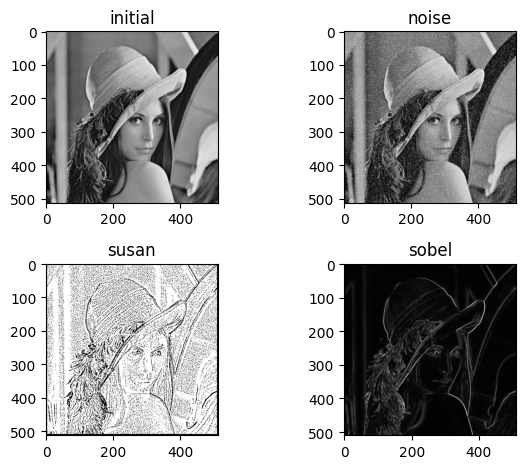

In [3]:
sobel_kernel_h = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
sobel_kernel_w = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])
img_n = noisz(img)
img_s = susan_f(img)
img_sh = juanji(img,sobel_kernel_h)
img_sw = juanji(img,sobel_kernel_w)
combined_edges = np.sqrt(img_sh**2 + img_sw**2)
plt.subplot(221)
plt.title("initial")
plt.imshow(img,plt.cm.gray)
plt.subplot(222)
plt.title("noise")
plt.imshow(img_n,plt.cm.gray)
plt.subplot(223)
plt.title("susan")
plt.imshow(img_s,plt.cm.gray)
plt.subplot(224)
plt.title("sobel")
plt.imshow(combined_edges,plt.cm.gray)
plt.tight_layout()
plt.show()

In [28]:
import cv2
import numpy as np

# 加载图片
image_path = 'chess.jpg'  # 替换为你的图片路径
image = cv2.imread(image_path)

# 如果图片加载成功，继续处理
if image is not None:
    # 将图片转换为灰度图
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    
    # 棋盘格的规格，例如8x6
    chessboard_size = (3,6)

    # 使用findChessboardCorners检测棋盘格角点
    ret, corners = cv2.findChessboardCorners(gray_image, chessboard_size, None)

    # 如果找到角点，绘制角点
    if ret:
        # 绘制角点
        cv2.drawChessboardCorners(image, chessboard_size, corners, ret)

        # 显示图片
        cv2.imshow('Chessboard Corners', image)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

        # 保存处理后的图片
        output_path = 'chess_corners.jpg'  # 替换为你想要保存的路径
        cv2.imwrite(output_path, image)
    else:
        print("未检测到棋盘格角点")
else:
    print("图片加载失败，请检查路径")